# U2-Net Small → LiteRT Conversion
Uses onnx2tf (works on Python 3.12). Downloads weights from rembg GitHub releases — no Google Drive, no auth.
Run all cells top to bottom. Last cell downloads `u2net_small.tflite`.

In [1]:
import sys
print(sys.version)  # confirm Python version

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
!pip install -q "numpy<2.0" onnx "onnxruntime>=1.18.0" onnxsim onnx2tf

# IMPORTANT: after this cell finishes, go to Runtime → Restart session
# then run all cells again. The numpy downgrade needs a fresh kernel to take effect.
import os
os.kill(os.getpid(), 9)  # auto-restarts the runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 693.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 k

In [1]:
# Download u2netp.onnx from rembg GitHub releases — reliable direct URL, no auth needed
import requests, os

ONNX_URL = "https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2netp.onnx"
ONNX_PATH = "u2netp.onnx"

if not os.path.exists(ONNX_PATH):
    print("Downloading u2netp.onnx...")
    r = requests.get(ONNX_URL, stream=True)
    r.raise_for_status()
    with open(ONNX_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print(f"Downloaded: {os.path.getsize(ONNX_PATH)/1e6:.1f} MB")

Downloaded: 4.6 MB


In [2]:
# Verify ONNX model with onnxruntime
import onnx
import onnxruntime as ort
import numpy as np

model = onnx.load(ONNX_PATH)
onnx.checker.check_model(model)

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
inp_name = sess.get_inputs()[0].name
inp_shape = sess.get_inputs()[0].shape
out_name = sess.get_outputs()[0].name
out_shape = sess.get_outputs()[0].shape

print(f"Input  : {inp_name} {inp_shape}")
print(f"Output : {out_name} {out_shape}")

test_in = np.random.rand(1, 3, 320, 320).astype(np.float32)
result = sess.run(None, {inp_name: test_in})[0]
print(f"Inference OK — output shape: {result.shape}, range [{result.min():.3f}, {result.max():.3f}]")

Input  : input.1 [1, 3, 320, 320]
Output : 1959 [1, 1, 320, 320]
Inference OK — output shape: (1, 1, 320, 320), range [0.000, 0.036]


In [3]:
# Simplify ONNX graph before conversion (reduces op count, improves TFLite compat)
import onnxsim

model_simplified, ok = onnxsim.simplify(model)
if ok:
    onnx.save(model_simplified, ONNX_PATH)
    print("ONNX simplified OK")
else:
    print("Simplification skipped — using original")

ONNX simplified OK


In [4]:
# Convert ONNX -> TFLite via onnx2tf
# onnx2tf auto-transposes NCHW -> NHWC for TFLite compatibility
import onnx2tf

OUT_DIR = "u2net_tflite_out"

onnx2tf.convert(
    input_onnx_file_path=ONNX_PATH,
    output_folder_path=OUT_DIR,
    not_use_onnxsim=True,   # already simplified above
    verbosity="warn",
)
print("Conversion done")

flatbuffer_direct lowering:   0%|          | 0/371 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.068s serialize=0.056s (sanitize=0.001s build=0.006s pack=0.041s output=0.009s) write=0.011s size=4.36MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.055s serialize=0.049s (sanitize=0.000s build=0.005s pack=0.043s output=0.001s) write=0.005s size=2.21MB
Conversion done


In [5]:
# Find and copy the .tflite output
import glob, shutil

OUTPUT = "u2net_small.tflite"
tflite_files = glob.glob(f"{OUT_DIR}/**/*.tflite", recursive=True)
print("Found:", tflite_files)

shutil.copy(tflite_files[0], OUTPUT)
print(f"Copied to {OUTPUT}")

Found: ['u2net_tflite_out/u2netp_float32.tflite', 'u2net_tflite_out/u2netp_float16.tflite']
Copied to u2net_small.tflite


In [6]:
# Verify with ai-edge-litert (lightweight LiteRT interpreter — no full TensorFlow needed)
!pip install -q ai-edge-litert

import numpy as np, os
from ai_edge_litert.interpreter import Interpreter

interp = Interpreter(model_path=OUTPUT)
interp.allocate_tensors()

inp_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]

print(f"Input  : {inp_d['shape']}  dtype: {inp_d['dtype']}")
print(f"Output : {out_d['shape']}  dtype: {out_d['dtype']}")

test_in = np.random.rand(*inp_d['shape']).astype(np.float32)
interp.set_tensor(inp_d['index'], test_in)
interp.invoke()
result = interp.get_tensor(out_d['index'])

print(f"Output range: [{result.min():.3f}, {result.max():.3f}]")
print(f"Model size  : {os.path.getsize(OUTPUT)/1e6:.2f} MB")
print("Verification OK — ready to bundle in Android assets/")

Input  : [  1 320 320   3]  dtype: <class 'numpy.float32'>
Output : [  1 320 320   1]  dtype: <class 'numpy.float32'>
Output range: [0.000, 0.040]
Model size  : 4.57 MB
Verification OK — ready to bundle in Android assets/


In [7]:
# Download to your machine
from google.colab import files
files.download(OUTPUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Upload a photo (or skip the upload prompt to use the sample image)


Saving IMG_0919.jpeg to IMG_0919 (1).jpeg
Image size: (5712, 4284)
Bounding box: (1392,267) → (4980,3842)


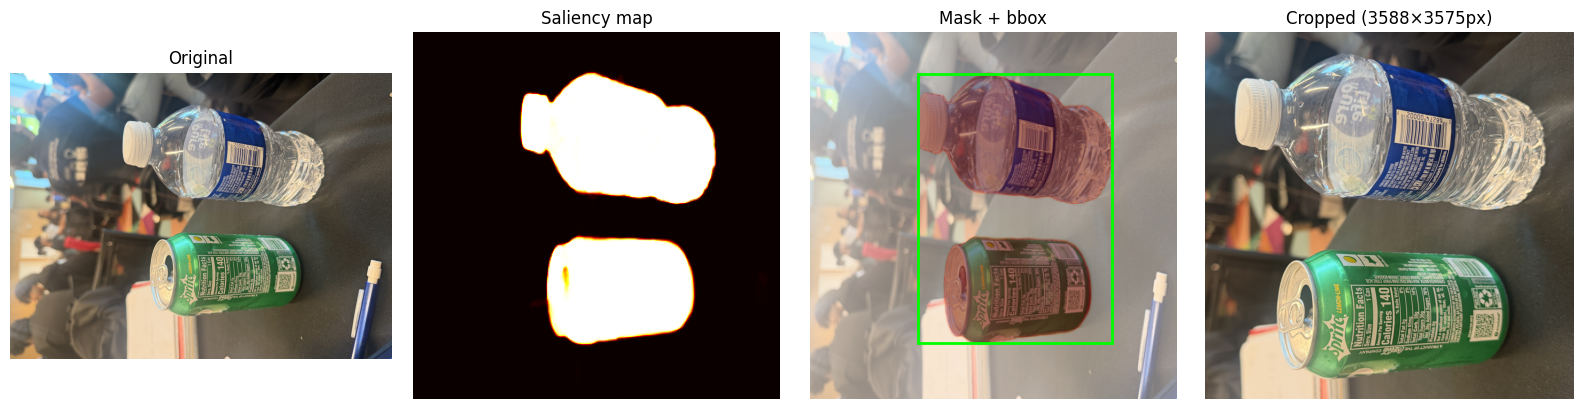

Saliency range: [0.000, 1.000]


In [13]:
# Visual end-to-end test — upload one of your texture photos or use the sample URL
from google.colab import files
from ai_edge_litert.interpreter import Interpreter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io, requests

# --- Load image ---
print("Upload a photo (or skip the upload prompt to use the sample image)")
try:
    uploaded = files.upload()
    img_name = list(uploaded.keys())[0]
    orig_img = Image.open(io.BytesIO(uploaded[img_name])).convert("RGB")
except Exception:
    # Fallback: grab a sample textured object from the web
    r = requests.get("https://upload.wikimedia.org/wikipedia/commons/thumb/1/1d/Ceramic_Jug.jpg/800px-Ceramic_Jug.jpg")
    orig_img = Image.open(io.BytesIO(r.content)).convert("RGB")
    print("Using sample ceramic jug image")

print(f"Image size: {orig_img.size}")

# --- Load model ---
interp = Interpreter(model_path=OUTPUT)
interp.allocate_tensors()
inp_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]

INPUT_H, INPUT_W = 320, 320
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# --- Preprocess ---
resized  = orig_img.resize((INPUT_W, INPUT_H), Image.BILINEAR)
img_arr  = np.array(resized, dtype=np.float32) / 255.0
img_norm = (img_arr - MEAN) / STD  # [320, 320, 3]

# Handle NCHW [1,3,H,W] vs NHWC [1,H,W,3] based on actual model input shape
if inp_d["shape"][1] == 3:
    inp_tensor = img_norm.transpose(2, 0, 1)[np.newaxis].astype(np.float32)
else:
    inp_tensor = img_norm[np.newaxis].astype(np.float32)

# --- Inference ---
interp.set_tensor(inp_d["index"], inp_tensor)
interp.invoke()
raw_out = interp.get_tensor(out_d["index"]).squeeze()  # [H, W]

# Normalize saliency map to [0, 1]
mask = (raw_out - raw_out.min()) / (raw_out.max() - raw_out.min() + 1e-8)

# --- Bounding box from thresholded mask ---
binary = mask > 0.5
rows = np.any(binary, axis=1)
cols = np.any(binary, axis=0)

if rows.any() and cols.any():
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    orig_w, orig_h = orig_img.size
    pad = 0.05
    x1 = max(0, int((cmin / INPUT_W - pad) * orig_w))
    y1 = max(0, int((rmin / INPUT_H - pad) * orig_h))
    x2 = min(orig_w, int((cmax / INPUT_W + pad) * orig_w))
    y2 = min(orig_h, int((rmax / INPUT_H + pad) * orig_h))
    cropped = orig_img.crop((x1, y1, x2, y2))
    has_box = True
else:
    has_box = False
    print("WARNING: no salient region detected above threshold 0.5")

# --- Plot ---
ncols = 4 if has_box else 3
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(orig_img);          axes[0].set_title("Original");         axes[0].axis("off")
axes[1].imshow(mask, cmap="hot");  axes[1].set_title("Saliency map");     axes[1].axis("off")

overlay = np.array(orig_img.resize((INPUT_W, INPUT_H)))
axes[2].imshow(overlay)
axes[2].imshow(mask, alpha=0.45, cmap="Reds")
if has_box:
    axes[2].add_patch(patches.Rectangle(
        (cmin, rmin), cmax - cmin, rmax - rmin,
        linewidth=2, edgecolor="lime", facecolor="none"
    ))
axes[2].set_title("Mask + bbox"); axes[2].axis("off")

if has_box:
    axes[3].imshow(cropped)
    axes[3].set_title(f"Cropped ({x2-x1}×{y2-y1}px)")
    axes[3].axis("off")
    print(f"Bounding box: ({x1},{y1}) → ({x2},{y2})")

plt.tight_layout()
plt.show()
print(f"Saliency range: [{mask.min():.3f}, {mask.max():.3f}]")

# For 2

Upload a photo (or dismiss to use the sample image)


Saving IMG_0916.jpeg to IMG_0916 (1).jpeg
Image size: (5712, 4284)
Raw components found: 7
Objects after noise filter (>1024px): 1


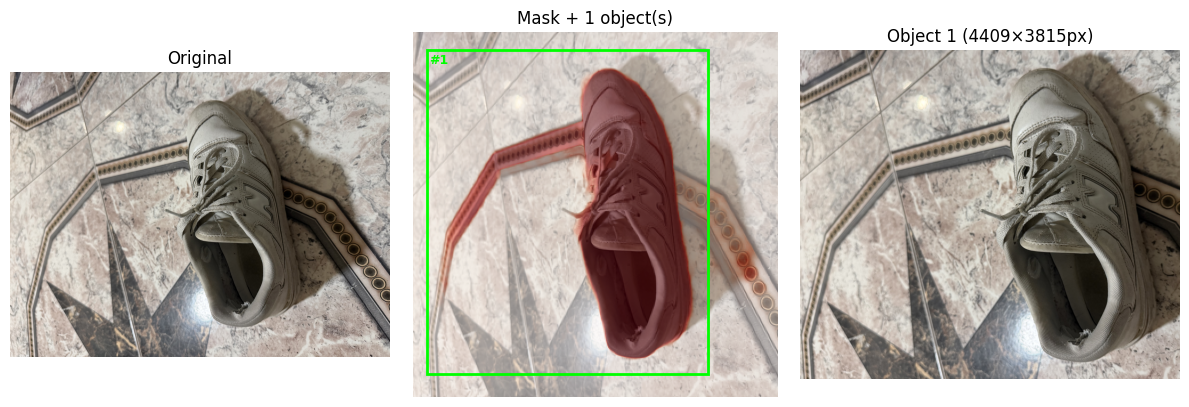

Object 1: bbox (232,214)→(4641,4029), mask area=21132px


In [15]:
# Visual end-to-end test — multi-object bounding boxes via connected component analysis
from google.colab import files
from ai_edge_litert.interpreter import Interpreter
from PIL import Image
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io, requests

# --- Load image ---
print("Upload a photo (or dismiss to use the sample image)")
try:
    uploaded = files.upload()
    img_name = list(uploaded.keys())[0]
    orig_img = Image.open(io.BytesIO(uploaded[img_name])).convert("RGB")
except Exception:
    r = requests.get("https://upload.wikimedia.org/wikipedia/commons/thumb/1/1d/Ceramic_Jug.jpg/800px-Ceramic_Jug.jpg")
    orig_img = Image.open(io.BytesIO(r.content)).convert("RGB")
    print("Using sample image")

orig_w, orig_h = orig_img.size
print(f"Image size: {orig_img.size}")

# --- Load model ---
interp = Interpreter(model_path=OUTPUT)
interp.allocate_tensors()
inp_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]

INPUT_H, INPUT_W = 320, 320
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# --- Preprocess ---
resized  = orig_img.resize((INPUT_W, INPUT_H), Image.BILINEAR)
img_arr  = np.array(resized, dtype=np.float32) / 255.0
img_norm = (img_arr - MEAN) / STD

if inp_d["shape"][1] == 3:  # NCHW
    inp_tensor = img_norm.transpose(2, 0, 1)[np.newaxis].astype(np.float32)
else:                        # NHWC
    inp_tensor = img_norm[np.newaxis].astype(np.float32)

# --- Inference ---
interp.set_tensor(inp_d["index"], inp_tensor)
interp.invoke()
raw_out = interp.get_tensor(out_d["index"]).squeeze()
mask = (raw_out - raw_out.min()) / (raw_out.max() - raw_out.min() + 1e-8)

# --- Connected component analysis ---
binary = mask > 0.5

# Minimum area: ignore components smaller than 1% of the 320x320 mask (noise rejection)
MIN_AREA_PX = int(INPUT_H * INPUT_W * 0.01)

labeled, n_components = ndimage.label(binary)
print(f"Raw components found: {n_components}")

boxes = []  # each entry: (x1, y1, x2, y2, area) in original image coords
for i in range(1, n_components + 1):
    comp = labeled == i
    area = int(comp.sum())
    if area < MIN_AREA_PX:
        continue

    rows = np.where(np.any(comp, axis=1))[0]
    cols = np.where(np.any(comp, axis=0))[0]
    rmin, rmax = rows[0], rows[-1]
    cmin, cmax = cols[0], cols[-1]

    pad = 0.05
    x1 = max(0, int((cmin / INPUT_W - pad) * orig_w))
    y1 = max(0, int((rmin / INPUT_H - pad) * orig_h))
    x2 = min(orig_w, int((cmax / INPUT_W + pad) * orig_w))
    y2 = min(orig_h, int((rmax / INPUT_H + pad) * orig_h))
    boxes.append((x1, y1, x2, y2, area))

# Sort largest to smallest so the primary object is first
boxes.sort(key=lambda b: b[4], reverse=True)
print(f"Objects after noise filter (>{MIN_AREA_PX}px): {len(boxes)}")

# --- Plot ---
crops = [orig_img.crop((x1, y1, x2, y2)) for x1, y1, x2, y2, _ in boxes]
ncols = 2 + len(crops)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(orig_img); axes[0].set_title("Original"); axes[0].axis("off")

# Mask + all bounding boxes
overlay = np.array(orig_img.resize((INPUT_W, INPUT_H)))
axes[1].imshow(overlay)
axes[1].imshow(mask, alpha=0.45, cmap="Reds")
colors = ["lime", "cyan", "yellow", "magenta"]
for idx, (x1, y1, x2, y2, area) in enumerate(boxes):
    cx1 = int(x1 / orig_w * INPUT_W)
    cy1 = int(y1 / orig_h * INPUT_H)
    cw  = int((x2 - x1) / orig_w * INPUT_W)
    ch  = int((y2 - y1) / orig_h * INPUT_H)
    color = colors[idx % len(colors)]
    axes[1].add_patch(patches.Rectangle((cx1, cy1), cw, ch,
                      linewidth=2, edgecolor=color, facecolor="none"))
    axes[1].text(cx1 + 2, cy1 + 12, f"#{idx+1}", color=color, fontsize=9, weight="bold")
axes[1].set_title(f"Mask + {len(boxes)} object(s)"); axes[1].axis("off")

for idx, (crop, (x1, y1, x2, y2, area)) in enumerate(zip(crops, boxes)):
    ax = axes[2 + idx]
    ax.imshow(crop)
    ax.set_title(f"Object {idx+1} ({x2-x1}×{y2-y1}px)")
    ax.axis("off")

plt.tight_layout()
plt.show()

for idx, (x1, y1, x2, y2, area) in enumerate(boxes):
    print(f"Object {idx+1}: bbox ({x1},{y1})→({x2},{y2}), mask area={area}px")